# S2Mosaic — Quick start

Mosaic an arbitrary lon/lat bounding box of Sentinel-2 imagery in a few cells. The demo below targets a deliberately challenging spot — Singapore's Marina Bay during the wet season — where most individual scenes are cloud-covered, so the cloud-masking + percentile-mosaic pipeline has real work to do.

For the full feature set (cross-tile bounds, lower-resolution outputs, custom CRS, etc.) see [`Example use - bounds.ipynb`](Example%20use%20-%20bounds.ipynb) and [`Example use - grid id.ipynb`](Example%20use%20-%20grid%20id.ipynb).

## 1. Install (Colab only)

The cell below installs `s2mosaic` only when running on Colab. If you've already got it installed locally, this is a no-op.

In [1]:
try:
    import google.colab  # type: ignore # noqa: F401

    %pip install -q s2mosaic
except ImportError:
    pass

## 2. Build a mosaic

We'll use Singapore's Marina Bay during the NE monsoon — a notoriously cloudy 4-month window where most individual scenes are partly to fully obscured. This is exactly where per-pixel cloud masking + a percentile mosaic earns its keep: only the clear pixels from each scene are kept, and the per-pixel median is taken across them.

The function searches the Microsoft Planetary Computer STAC catalog, fetches the matching scenes, runs cloud masking, and returns the composite as a NumPy array plus a rasterio profile.

In [ ]:
from s2mosaic import mosaic

# To stream pipeline progress logs, uncomment:
# import s2mosaic; s2mosaic.set_log_level("INFO")

# ~8km x 4km AOI over Marina Bay, Singapore (lon/lat, EPSG:4326)
bounds = (103.82, 1.265, 103.89, 1.30)

array, profile = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=11,  # NE monsoon — wet & cloudy
    duration_months=4,  # span Nov 2023 – Feb 2024
    required_bands=["B04", "B03", "B02"],  # red, green, blue
    mosaic_method="median",
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

## 3. Display the result

Quick percentile-stretch RGB plot. For a saved GeoTIFF instead, pass `output_dir=Path("output")` to `mosaic()` — it will then return the file path.

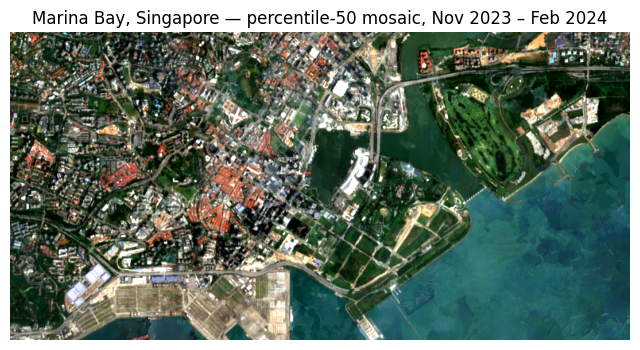

In [3]:
import numpy as np
from matplotlib import pyplot as plt

# Stretch to the 2nd–98th percentile of valid pixels
rgb = array.transpose(1, 2, 0).astype(float)
valid = rgb[rgb > 0]
lo, hi = np.percentile(valid, [2, 98])
rgb_disp = ((rgb - lo) / (hi - lo)).clip(0, 1)

plt.figure(figsize=(8, 6))
plt.imshow(rgb_disp)
plt.title("Marina Bay, Singapore — percentile-50 mosaic, Nov 2023 – Feb 2024")
plt.axis("off")
plt.show()

## What next?

- Switch to a different area: change the four numbers in `bounds`.
- Get a 4-band stack (R, G, B, NIR): `required_bands=["B04", "B03", "B02", "B08"]`.
- Mosaic an entire MGRS tile instead: pass `grid_id="50HMH"` (no `bounds`).
- Running on a CPU-only machine? Pass `cloud_mask="SCL"` to skip the deep-learning model and use the L2A Scene Classification Layer instead — much cheaper, slightly less accurate.

See the [README](https://github.com/DPIRD-DMA/S2Mosaic#advanced-usage) for the full argument reference.